In [2]:
# 1. CIFAR-10 다운로드 (Kaggle 버전 -- 구글 드라이브 마운트 불필요)
# Settings > Internet: On 으로 켜져 있어야 다운로드가 됩니다.
import os
import urllib.request

work_dir = '/kaggle/working'
destination_path = os.path.join(work_dir, 'cifar10.tgz')
cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'

if not os.path.exists(destination_path):
    print("CIFAR-10 다운로드 시작...")
    urllib.request.urlretrieve(cifar_url, destination_path)
    print(f"완료! ({os.path.getsize(destination_path) / (1024*1024):.2f} MB)")
else:
    print("이미 다운로드된 cifar10.tgz가 있습니다.")

print("")
print("세션이 끊기면 /kaggle/working이 초기화됩니다.")
print("Stage 1-2를 한 세션 안에서 이어서 실행하는 것을 권장합니다 (총 약 52분).")

CIFAR-10 다운로드 시작...
완료! (128.85 MB)

세션이 끊기면 /kaggle/working이 초기화됩니다.
Stage 1-2를 한 세션 안에서 이어서 실행하는 것을 권장합니다 (총 약 52분).


In [3]:
import os
import time
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}\n")

# ==========================================
# 1. 초고속 데이터 압축 해제 (Drive -> Colab Local)
# ==========================================
drive_zip_path = '/kaggle/working/cifar10.tgz'
local_extract_path = '/kaggle/working/'
local_data_path = '/kaggle/working/cifar10'  # fast.ai 압축을 풀면 나오는 기본 폴더명

if not os.path.exists(local_data_path):
    print("📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path=local_extract_path)
    print("✅ 로컬 압축 해제 완료!\n")
else:
    print("✨ 이미 코랩 로컬에 데이터가 압축 해제되어 있습니다.\n")

# ==========================================
# 2. 데이터셋 및 데이터로더 설정 (Data Augmentation)
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'), transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"📊 학습 데이터: {len(train_dataset)}장 | 테스트 데이터: {len(test_dataset)}장 준비 완료\n")

🖥️ 현재 사용 중인 장치: cuda

📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)


/tmp/ipykernel_59/2738238541.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_extract_path)


✅ 로컬 압축 해제 완료!

📊 학습 데이터: 50000장 | 테스트 데이터: 10000장 준비 완료



In [4]:
# ==========================================
# 3. 모델 정의 (ResNet-18 for CIFAR-10)
# ==========================================
NUM_CLASSES = 10

def build_model(num_classes=NUM_CLASSES):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

model = build_model()
print(f"✅ ResNet-18 ({NUM_CLASSES} classes) 준비 완료!\n")

✅ ResNet-18 (10 classes) 준비 완료!



In [5]:
# ==========================================
# 4. Lion 옵티마이저
# ==========================================
class Lion(optim.Optimizer):
    """
    Chen et al., 2023, "Symbolic Discovery of Optimization Algorithms"

    update = sign(β₁·m + (1-β₁)·g)      ← 부호만 사용 (크기 정보 버림)
    m      = β₂·m + (1-β₂)·g            ← 모멘텀은 별도의 β₂로 갱신

    특징
    - 상태가 모멘텀 하나뿐 (AdamW는 두 개) → 메모리 절반
    - 업데이트 크기가 항상 lr로 고정 (sign이므로) → Muon의 "균일 스텝"과 통하는 성질
    - 구현이 매우 단순해 실수 여지가 적다

    ⚠️ lr은 AdamW의 1/3~1/10, weight_decay는 3~10배가 정석 (업데이트 크기가 고정이라)
    """
    def __init__(self, params, lr=2e-4, betas=(0.9, 0.99), weight_decay=0.5):
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            wd = group['weight_decay']
            beta1, beta2 = group['betas']
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                if 'exp_avg' not in state:
                    state['exp_avg'] = torch.zeros_like(p)
                exp_avg = state['exp_avg']
                grad = p.grad

                # decoupled weight decay
                if wd != 0:
                    p.mul_(1 - lr * wd)

                # update = sign(beta1*m + (1-beta1)*g)
                update = exp_avg.mul(beta1).add_(grad, alpha=1 - beta1).sign_()
                p.add_(update, alpha=-lr)

                # m = beta2*m + (1-beta2)*g
                exp_avg.mul_(beta2).add_(grad, alpha=1 - beta2)
        return loss


def build_optimizer(model, name, lr, weight_decay):
    if name == 'lion':
        return Lion(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif name == 'adamw':
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"unknown optimizer: {name}")

print("✅ Lion 옵티마이저 정의 완료!\n")

✅ Lion 옵티마이저 정의 완료!



In [6]:
# ==========================================
# 5. SAMAscent — 옵티마이저 독립적인 SAM perturbation
# ==========================================
class SAMAscent:
    """
    SAM을 '옵티마이저'가 아니라 '그래디언트 변환기'로 분리.
    perturbation만 담당하고 실제 step은 외부 옵티마이저에게 맡기므로,
    옵티마이저를 교체하지 않고도 SAM을 켤 수 있다 → 모멘텀 상태가 완벽히 연속.

    (v1의 실패 원인이었던 '옵티마이저 교체 시 모멘텀 리셋'을 구조적으로 차단)
    """
    def __init__(self, params, rho=0.0):
        self.params = [p for p in params if p.requires_grad]
        self.rho = rho
        self._e_w = {}

    def set_rho(self, rho):
        self.rho = rho

    @torch.no_grad()
    def _grad_norm(self):
        grads = [p.grad.norm(p=2) for p in self.params if p.grad is not None]
        if not grads:
            return torch.tensor(0.0)
        return torch.norm(torch.stack(grads), p=2)

    @torch.no_grad()
    def ascent(self):
        if self.rho <= 0:
            return False
        gn = self._grad_norm()
        if gn.item() < 1e-12:
            return False
        scale = self.rho / (gn + 1e-12)
        self._e_w.clear()
        for p in self.params:
            if p.grad is None:
                continue
            e_w = p.grad * scale.to(p.device)
            p.add_(e_w)
            self._e_w[p] = e_w
        return True

    @torch.no_grad()
    def restore(self):
        for p, e_w in self._e_w.items():
            p.sub_(e_w)
        self._e_w.clear()

print("✅ SAMAscent 정의 완료!\n")

✅ SAMAscent 정의 완료!



In [7]:
# ==========================================
# 6. WSD 스케줄 + 진단 함수
# ==========================================
import math

def wsd_lr(epoch, total_epochs, peak_lr, warmup_epochs, decay_epochs,
           decay_shape='linear', final_frac=0.0):
    """
    Warmup-Stable-Decay 학습률.

    warmup : 0 → peak_lr 선형 상승
    stable : peak_lr 유지  ← 이 구간은 어디서든 잘라서 decay로 분기 가능
    decay  : peak_lr → peak_lr*final_frac

    decay_shape: 'linear' 또는 'one_minus_sqrt' (후자는 초반에 더 급하게 떨어짐)
    """
    stable_end = total_epochs - decay_epochs
    if epoch < warmup_epochs:
        return peak_lr * (epoch + 1) / warmup_epochs
    if epoch < stable_end:
        return peak_lr
    progress = (epoch - stable_end + 1) / decay_epochs
    progress = min(1.0, max(0.0, progress))
    if decay_shape == 'one_minus_sqrt':
        factor = 1.0 - math.sqrt(progress)
    else:
        factor = 1.0 - progress
    return peak_lr * (final_frac + (1 - final_frac) * factor)


def set_lr(optimizer, lr):
    for g in optimizer.param_groups:
        g['lr'] = lr


def measure_sharpness(model, criterion, probe_batches, device, rho=0.05):
    """고정 probe 배치로 L(w+eps)-L(w) 측정. rho는 항상 0.05 고정 → 모든 run 비교 가능"""
    was_training = model.training
    model.eval()
    diffs = []
    for inputs, targets in probe_batches:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            loss_w = criterion(model(inputs), targets).item()

        model.zero_grad(set_to_none=True)
        criterion(model(inputs), targets).backward()
        grads = [p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]
        scale = rho / (torch.norm(torch.stack(grads), p=2) + 1e-12)

        e_ws = []
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w)
                e_ws.append((p, e_w))
            loss_w_eps = criterion(model(inputs), targets).item()
            for p, e_w in e_ws:
                p.sub_(e_w)
        model.zero_grad(set_to_none=True)
        diffs.append(loss_w_eps - loss_w)

    if was_training:
        model.train()
    return sum(diffs) / len(diffs)


def evaluate(model_to_eval, loader):
    model_to_eval.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            _, predicted = model_to_eval(inputs).max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total


def run_epochs(model, optimizer, sam, criterion, train_loader, test_loader,
               probe_batches, device, epoch_range, cfg, history, sharpness_history,
               rho_fn=None, tag="RUN"):
    """
    epoch_range의 각 에폭을 학습. rho_fn(epoch)가 0보다 크면 SAM overlay 적용.
    Stage 1(stable)과 Stage 2(decay)가 이 함수를 공유하므로 코드 경로가 완전히 동일하다.
    """
    for epoch in epoch_range:
        lr_now = wsd_lr(epoch, cfg['total_epochs'], cfg['peak_lr'],
                        cfg['warmup_epochs'], cfg['decay_epochs'],
                        cfg['decay_shape'], cfg['final_frac'])
        set_lr(optimizer, lr_now)
        rho_now = rho_fn(epoch) if rho_fn is not None else 0.0
        sam.set_rho(rho_now)

        model.train()
        running_loss, running_gap, running_gnorm = 0.0, 0.0, 0.0
        correct, total, n_batches = 0, 0, 0
        t0 = time.time()

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad(set_to_none=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            with torch.no_grad():
                gn = torch.norm(torch.stack([
                    p.grad.norm(p=2) for p in model.parameters()
                    if p.grad is not None]), p=2).item()
            running_gnorm += gn

            gap = 0.0
            if sam.ascent():
                optimizer.zero_grad(set_to_none=True)
                loss_adv = criterion(model(inputs), targets)
                loss_adv.backward()
                gap = loss_adv.item() - loss.item()
                sam.restore()

            if cfg['grad_clip'] is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            optimizer.step()

            running_loss += loss.item()
            running_gap += gap
            n_batches += 1

        dt = time.time() - t0
        train_loss = running_loss / n_batches
        train_acc = 100. * correct / total
        test_acc = evaluate(model, test_loader)

        history['epoch'].append(epoch + 1)
        history['lr'].append(lr_now)
        history['rho'].append(rho_now)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['grad_norm'].append(running_gnorm / n_batches)
        history['ascent_gap'].append(running_gap / n_batches)
        history['time'].append(dt)

        sharp_str = ""
        if (epoch + 1) % cfg['sharpness_interval'] == 0 or epoch == epoch_range[-1]:
            sv = measure_sharpness(model, criterion, probe_batches, device, rho=0.05)
            sharpness_history['epoch'].append(epoch + 1)
            sharpness_history['sharpness'].append(sv)
            sharp_str = f" | Sharp: {sv:.4f}"

        stable_end = cfg['total_epochs'] - cfg['decay_epochs']
        if epoch < cfg['warmup_epochs']:
            ph = "warmup"
        elif epoch < stable_end:
            ph = "stable"
        else:
            ph = "decay "
        print(f"[{tag}|{ph}] Ep [{epoch+1}/{cfg['total_epochs']}] | {dt:.1f}s | "
              f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}% | "
              f"lr: {lr_now:.5f} | rho: {rho_now:.4f}{sharp_str}")

print("✅ WSD 스케줄 + 학습 루프 정의 완료!\n")

✅ WSD 스케줄 + 학습 루프 정의 완료!



In [8]:
# ==========================================
# 7. 고정 probe 배치  ★ 학습 셀들보다 먼저, 딱 한 번만 실행
# ==========================================
from torch.utils.data import Subset, DataLoader

_g = torch.Generator().manual_seed(1234)
_probe_idx = torch.randperm(len(train_dataset), generator=_g)[:384].tolist()
_probe_loader = DataLoader(Subset(train_dataset, _probe_idx), batch_size=128, shuffle=False)
probe_batches = [(x.clone(), y.clone()) for x, y in _probe_loader]

print(f"✅ 고정 probe {len(probe_batches)}배치 ({sum(len(y) for _, y in probe_batches)}장)")
print("   → 모든 run이 동일 데이터로 sharpness 측정 (직접 비교 가능)\n")

✅ 고정 probe 3배치 (384장)
   → 모든 run이 동일 데이터로 sharpness 측정 (직접 비교 가능)



In [9]:
# ==========================================
# 8. Stage 1 — warmup + stable (한 번만 실행, 체크포인트 저장)
# ==========================================
FAST_OPT = 'lion'        # 'lion' | 'adamw'
PEAK_LR = 2e-4 if FAST_OPT == 'lion' else 1e-3
WEIGHT_DECAY = 0.5 if FAST_OPT == 'lion' else 0.05

CFG = {
    'total_epochs': 50,
    'warmup_epochs': 3,
    'decay_epochs': 10,       # 마지막 10에폭이 decay = SAM을 켜는 구간
    'decay_shape': 'linear',  # 'linear' | 'one_minus_sqrt'
    'final_frac': 0.0,
    'peak_lr': PEAK_LR,
    'grad_clip': 1.0,
    'sharpness_interval': 2,
    'fast_opt': FAST_OPT,
    'weight_decay': WEIGHT_DECAY,
}
STABLE_END = CFG['total_epochs'] - CFG['decay_epochs']   # = 40

torch.manual_seed(42)
model = build_model()
optimizer = build_optimizer(model, FAST_OPT, PEAK_LR, WEIGHT_DECAY)
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss()

history = {k: [] for k in ['epoch','lr','rho','train_loss','train_acc',
                            'test_acc','grad_norm','ascent_gap','time']}
sharpness_history = {'epoch': [], 'sharpness': []}

print(f"🚀 Stage 1 — {FAST_OPT.upper()} + WSD (warmup {CFG['warmup_epochs']} + "
      f"stable {STABLE_END - CFG['warmup_epochs']} = {STABLE_END} epochs)\n")

run_epochs(model, optimizer, sam, criterion, train_loader, test_loader,
           probe_batches, device, range(0, STABLE_END), CFG,
           history, sharpness_history, rho_fn=None, tag="S1")

# ---- 체크포인트 저장 (모델 + 옵티마이저 상태 모두) ----
save_dir = '/kaggle/working/wsd_experiments'
os.makedirs(save_dir, exist_ok=True)
ckpt_path = os.path.join(save_dir, f'stage1_{FAST_OPT}_ep{STABLE_END}.pt')

torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict(),   # ★ 모멘텀 상태까지 저장해야 분기가 공정함
    'cfg': CFG,
    'history': history,
    'sharpness_history': sharpness_history,
    'stable_end': STABLE_END,
}, ckpt_path)

stable_sharp = sharpness_history['sharpness'][-1]
print(f"\n💾 체크포인트 저장: {ckpt_path}")
print(f"   Stage 1 종료 — Train {history['train_acc'][-1]:.2f}% | "
      f"Test {history['test_acc'][-1]:.2f}% | Sharpness {stable_sharp:.4f}")
print(f"   총 {sum(history['time'])/60:.1f}분")
print(f"\n👉 이제 셀 9를 SAM_IN_DECAY=False / True 로 두 번 실행하세요.")

🚀 Stage 1 — LION + WSD (warmup 3 + stable 37 = 40 epochs)

[S1|warmup] Ep [1/50] | 22.1s | Loss: 1.6268 | Train: 40.46% | Test: 55.03% | lr: 0.00007 | rho: 0.0000
[S1|warmup] Ep [2/50] | 21.0s | Loss: 1.1864 | Train: 57.42% | Test: 63.77% | lr: 0.00013 | rho: 0.0000 | Sharp: 0.9493
[S1|warmup] Ep [3/50] | 21.6s | Loss: 0.9969 | Train: 64.57% | Test: 67.73% | lr: 0.00020 | rho: 0.0000
[S1|stable] Ep [4/50] | 22.5s | Loss: 0.8719 | Train: 69.36% | Test: 72.35% | lr: 0.00020 | rho: 0.0000 | Sharp: 0.3837
[S1|stable] Ep [5/50] | 23.5s | Loss: 0.7905 | Train: 72.28% | Test: 73.50% | lr: 0.00020 | rho: 0.0000
[S1|stable] Ep [6/50] | 22.6s | Loss: 0.7328 | Train: 74.50% | Test: 75.52% | lr: 0.00020 | rho: 0.0000 | Sharp: 0.5542
[S1|stable] Ep [7/50] | 22.4s | Loss: 0.6833 | Train: 76.15% | Test: 76.96% | lr: 0.00020 | rho: 0.0000
[S1|stable] Ep [8/50] | 22.8s | Loss: 0.6426 | Train: 77.66% | Test: 77.45% | lr: 0.00020 | rho: 0.0000 | Sharp: 0.2970
[S1|stable] Ep [9/50] | 22.7s | Loss: 0.6179 

In [15]:
# ==========================================
# 9. Stage 2 — 체크포인트에서 분기해 decay 실행
# ==========================================
# ┌──────────────────────────────────────────────────────────────┐
# │ 이 셀을 두 번 실행합니다 (셀 8은 다시 돌리지 않음!)            │
# │   1회차: SAM_IN_DECAY = False  → 대조군 (순수 WSD)            │
# │   2회차: SAM_IN_DECAY = True   → 실험군 (WSD + SAM overlay)   │
# │ 둘 다 완전히 동일한 가중치·옵티마이저 상태에서 출발합니다.     │
# └──────────────────────────────────────────────────────────────┘
SAM_IN_DECAY = False
RHO_MAX = 0.05
RHO_RAMP_EPOCHS = 3      # decay 시작 후 rho를 0→RHO_MAX로 올리는 에폭 수

save_dir = '/kaggle/working/wsd_experiments'
ckpt_path = os.path.join(save_dir, f'stage1_{FAST_OPT}_ep{STABLE_END}.pt')
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

CFG = ckpt['cfg']
STABLE_END = ckpt['stable_end']
CFG['decay_epochs'] = 20
CFG['total_epochs'] = STABLE_END + CFG['decay_epochs']   # 40 + 20 = 60  ★ 이 줄이 빠졌었습니다

# ---- 체크포인트에서 정확히 복원 ----
model = build_model()
model.load_state_dict(ckpt['model'])
optimizer = build_optimizer(model, CFG['fast_opt'], CFG['peak_lr'], CFG['weight_decay'])
optimizer.load_state_dict(ckpt['optimizer'])   # ★ 모멘텀 상태 복원
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss()

# Stage 1 히스토리를 이어받아 곡선이 연결되게 함
history = {k: list(v) for k, v in ckpt['history'].items()}
sharpness_history = {k: list(v) for k, v in ckpt['sharpness_history'].items()}

def rho_fn(epoch):
    """decay 구간에서만 rho를 올림. 시작 직후 급변을 막기 위해 램프 적용."""
    if not SAM_IN_DECAY:
        return 0.0
    prog = (epoch - STABLE_END + 1) / max(1, RHO_RAMP_EPOCHS)
    return RHO_MAX * min(1.0, max(0.0, prog))

ARM = 'sam_on' if SAM_IN_DECAY else 'sam_off'
print(f"🚀 Stage 2 [{ARM}] — decay {CFG['decay_epochs']} epochs "
      f"(공통 출발점: ep{STABLE_END}, Test {ckpt['history']['test_acc'][-1]:.2f}%)\n")

run_epochs(model, optimizer, sam, criterion, train_loader, test_loader,
           probe_batches, device, range(STABLE_END, CFG['total_epochs']), CFG,
           history, sharpness_history, rho_fn=rho_fn, tag=f"S2-{ARM}")

# ---- 결과 저장 ----
import json
from datetime import datetime

best_acc = max(history['test_acc'])
best_epoch = history['epoch'][history['test_acc'].index(best_acc)]
decay_start_test = ckpt['history']['test_acc'][-1]
decay_start_sharp = ckpt['sharpness_history']['sharpness'][-1]

record = {
    'arm': ARM,
    'fast_opt': CFG['fast_opt'],
    'sam_in_decay': SAM_IN_DECAY,
    'rho_max': RHO_MAX if SAM_IN_DECAY else 0.0,
    'cfg': CFG,
    'results': {
        'decay_start_test_acc': decay_start_test,
        'decay_start_sharpness': decay_start_sharp,
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc,
        'best_epoch': best_epoch,
        'final_gap': history['train_acc'][-1] - history['test_acc'][-1],
        'final_sharpness': sharpness_history['sharpness'][-1],
        'decay_time_min': sum(history['time'][STABLE_END:]) / 60,
    },
    'history': history,
    'sharpness_history': sharpness_history,
}
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
with open(os.path.join(save_dir, f"arm_{CFG['fast_opt']}_{ARM}_{ts}.json"),
          'w', encoding='utf-8') as f:
    json.dump(record, f, ensure_ascii=False, indent=2)

r = record['results']
print(f"\n🎉 [{ARM}] 완료")
print(f"   decay 시작   : Test {decay_start_test:.2f}% | Sharp {decay_start_sharp:.4f}")
print(f"   decay 종료   : Test {r['final_test_acc']:.2f}% | Sharp {r['final_sharpness']:.4f}")
print(f"   변화         : Test {r['final_test_acc']-decay_start_test:+.2f}%p | "
      f"Sharp {r['final_sharpness']-decay_start_sharp:+.4f}")
print(f"   최고 Test    : {best_acc:.2f}% (ep {best_epoch})")
print(f"   decay 소요   : {r['decay_time_min']:.1f}분")

🚀 Stage 2 [sam_off] — decay 20 epochs (공통 출발점: ep40, Test 84.20%)

[S2-sam_off|decay ] Ep [41/60] | 22.7s | Loss: 0.3173 | Train: 88.96% | Test: 84.37% | lr: 0.00019 | rho: 0.0000
[S2-sam_off|decay ] Ep [42/60] | 23.4s | Loss: 0.3066 | Train: 89.25% | Test: 84.06% | lr: 0.00018 | rho: 0.0000 | Sharp: 0.2077
[S2-sam_off|decay ] Ep [43/60] | 22.5s | Loss: 0.2995 | Train: 89.54% | Test: 85.44% | lr: 0.00017 | rho: 0.0000
[S2-sam_off|decay ] Ep [44/60] | 22.5s | Loss: 0.2840 | Train: 89.92% | Test: 84.72% | lr: 0.00016 | rho: 0.0000 | Sharp: 0.1839
[S2-sam_off|decay ] Ep [45/60] | 22.7s | Loss: 0.2771 | Train: 90.23% | Test: 85.24% | lr: 0.00015 | rho: 0.0000
[S2-sam_off|decay ] Ep [46/60] | 22.7s | Loss: 0.2645 | Train: 90.66% | Test: 85.26% | lr: 0.00014 | rho: 0.0000 | Sharp: 0.2274
[S2-sam_off|decay ] Ep [47/60] | 22.5s | Loss: 0.2513 | Train: 91.08% | Test: 86.06% | lr: 0.00013 | rho: 0.0000
[S2-sam_off|decay ] Ep [48/60] | 22.5s | Loss: 0.2349 | Train: 91.86% | Test: 85.41% | lr: 0.0

In [16]:
# ==========================================
# 9. Stage 2 — 체크포인트에서 분기해 decay 실행
# ==========================================
# ┌──────────────────────────────────────────────────────────────┐
# │ 이 셀을 두 번 실행합니다 (셀 8은 다시 돌리지 않음!)            │
# │   1회차: SAM_IN_DECAY = False  → 대조군 (순수 WSD)            │
# │   2회차: SAM_IN_DECAY = True   → 실험군 (WSD + SAM overlay)   │
# │ 둘 다 완전히 동일한 가중치·옵티마이저 상태에서 출발합니다.     │
# └──────────────────────────────────────────────────────────────┘
SAM_IN_DECAY = True
RHO_MAX = 0.05
RHO_RAMP_EPOCHS = 3      # decay 시작 후 rho를 0→RHO_MAX로 올리는 에폭 수

save_dir = '/kaggle/working/wsd_experiments'
ckpt_path = os.path.join(save_dir, f'stage1_{FAST_OPT}_ep{STABLE_END}.pt')
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

CFG = ckpt['cfg']
STABLE_END = ckpt['stable_end']
CFG['decay_epochs'] = 20
CFG['total_epochs'] = STABLE_END + CFG['decay_epochs']   # 40 + 20 = 60  ★ 이 줄이 빠졌었습니다

# ---- 체크포인트에서 정확히 복원 ----
model = build_model()
model.load_state_dict(ckpt['model'])
optimizer = build_optimizer(model, CFG['fast_opt'], CFG['peak_lr'], CFG['weight_decay'])
optimizer.load_state_dict(ckpt['optimizer'])   # ★ 모멘텀 상태 복원
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss()

# Stage 1 히스토리를 이어받아 곡선이 연결되게 함
history = {k: list(v) for k, v in ckpt['history'].items()}
sharpness_history = {k: list(v) for k, v in ckpt['sharpness_history'].items()}

def rho_fn(epoch):
    """decay 구간에서만 rho를 올림. 시작 직후 급변을 막기 위해 램프 적용."""
    if not SAM_IN_DECAY:
        return 0.0
    prog = (epoch - STABLE_END + 1) / max(1, RHO_RAMP_EPOCHS)
    return RHO_MAX * min(1.0, max(0.0, prog))

ARM = 'sam_on' if SAM_IN_DECAY else 'sam_off'
print(f"🚀 Stage 2 [{ARM}] — decay {CFG['decay_epochs']} epochs "
      f"(공통 출발점: ep{STABLE_END}, Test {ckpt['history']['test_acc'][-1]:.2f}%)\n")

run_epochs(model, optimizer, sam, criterion, train_loader, test_loader,
           probe_batches, device, range(STABLE_END, CFG['total_epochs']), CFG,
           history, sharpness_history, rho_fn=rho_fn, tag=f"S2-{ARM}")

# ---- 결과 저장 ----
import json
from datetime import datetime

best_acc = max(history['test_acc'])
best_epoch = history['epoch'][history['test_acc'].index(best_acc)]
decay_start_test = ckpt['history']['test_acc'][-1]
decay_start_sharp = ckpt['sharpness_history']['sharpness'][-1]

record = {
    'arm': ARM,
    'fast_opt': CFG['fast_opt'],
    'sam_in_decay': SAM_IN_DECAY,
    'rho_max': RHO_MAX if SAM_IN_DECAY else 0.0,
    'cfg': CFG,
    'results': {
        'decay_start_test_acc': decay_start_test,
        'decay_start_sharpness': decay_start_sharp,
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc,
        'best_epoch': best_epoch,
        'final_gap': history['train_acc'][-1] - history['test_acc'][-1],
        'final_sharpness': sharpness_history['sharpness'][-1],
        'decay_time_min': sum(history['time'][STABLE_END:]) / 60,
    },
    'history': history,
    'sharpness_history': sharpness_history,
}
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
with open(os.path.join(save_dir, f"arm_{CFG['fast_opt']}_{ARM}_{ts}.json"),
          'w', encoding='utf-8') as f:
    json.dump(record, f, ensure_ascii=False, indent=2)

r = record['results']
print(f"\n🎉 [{ARM}] 완료")
print(f"   decay 시작   : Test {decay_start_test:.2f}% | Sharp {decay_start_sharp:.4f}")
print(f"   decay 종료   : Test {r['final_test_acc']:.2f}% | Sharp {r['final_sharpness']:.4f}")
print(f"   변화         : Test {r['final_test_acc']-decay_start_test:+.2f}%p | "
      f"Sharp {r['final_sharpness']-decay_start_sharp:+.4f}")
print(f"   최고 Test    : {best_acc:.2f}% (ep {best_epoch})")
print(f"   decay 소요   : {r['decay_time_min']:.1f}분")

🚀 Stage 2 [sam_on] — decay 20 epochs (공통 출발점: ep40, Test 84.20%)

[S2-sam_on|decay ] Ep [41/60] | 44.9s | Loss: 0.3172 | Train: 88.97% | Test: 84.78% | lr: 0.00019 | rho: 0.0167
[S2-sam_on|decay ] Ep [42/60] | 42.2s | Loss: 0.3050 | Train: 89.36% | Test: 84.87% | lr: 0.00018 | rho: 0.0333 | Sharp: 0.1325
[S2-sam_on|decay ] Ep [43/60] | 43.3s | Loss: 0.2877 | Train: 90.21% | Test: 85.47% | lr: 0.00017 | rho: 0.0500
[S2-sam_on|decay ] Ep [44/60] | 42.7s | Loss: 0.2756 | Train: 90.61% | Test: 85.37% | lr: 0.00016 | rho: 0.0500 | Sharp: 0.1327
[S2-sam_on|decay ] Ep [45/60] | 43.0s | Loss: 0.2661 | Train: 91.02% | Test: 85.71% | lr: 0.00015 | rho: 0.0500
[S2-sam_on|decay ] Ep [46/60] | 42.8s | Loss: 0.2546 | Train: 91.28% | Test: 86.02% | lr: 0.00014 | rho: 0.0500 | Sharp: 0.1271
[S2-sam_on|decay ] Ep [47/60] | 42.9s | Loss: 0.2412 | Train: 91.89% | Test: 86.19% | lr: 0.00013 | rho: 0.0500
[S2-sam_on|decay ] Ep [48/60] | 43.0s | Loss: 0.2271 | Train: 92.34% | Test: 86.11% | lr: 0.00012 | rh

/tmp/ipykernel_59/3581660857.py:54: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/3581660857.py:54: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/3581660857.py:54: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/3581660857.py:54: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/3581660857.py:54: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/3581660857.py:54: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/3581660857.py:54: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

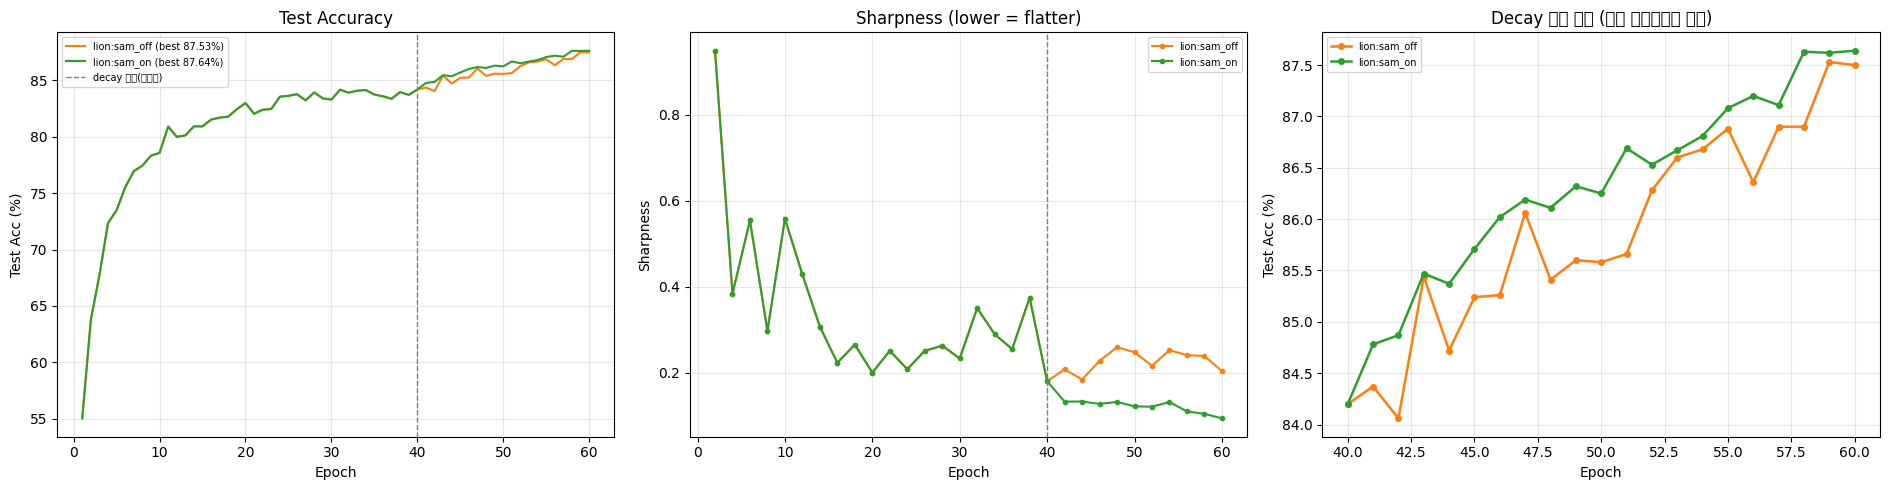

분기                        출발Test    최종Test       Δ    최종Sharp      분
----------------------------------------------------------------------
lion:sam_off              84.20%    87.50%  +3.30p     0.2036    7.5
lion:sam_on               84.20%    87.64%  +3.44p     0.0935   14.3
----------------------------------------------------------------------

※ 두 분기는 완전히 동일한 가중치·옵티마이저 상태에서 출발했으므로,
   차이는 오직 SAM 유무에서 비롯됩니다.


In [17]:
# ==========================================
# 10. 두 분기 비교 (양쪽 다 실행한 뒤)
# ==========================================
import glob, json
import matplotlib.pyplot as plt

save_dir = '/kaggle/working/wsd_experiments'
arms = {}
for fp in sorted(glob.glob(os.path.join(save_dir, 'arm_*.json'))):
    with open(fp, encoding='utf-8') as f:
        rec = json.load(f)
    arms[f"{rec['fast_opt']}:{rec['arm']}"] = rec   # 같은 키면 최신 것이 남음

if len(arms) < 2:
    print(f"⚠️ 분기가 {len(arms)}개뿐입니다. 셀 9를 SAM_IN_DECAY=False/True로 각각 실행하세요.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    colors = {}
    for i, k in enumerate(arms):
        colors[k] = 'tab:green' if 'sam_on' in k else 'tab:orange'

    stable_end = list(arms.values())[0]['cfg']['total_epochs'] - \
                 list(arms.values())[0]['cfg']['decay_epochs']

    # 1. Test Acc — decay 구간 확대
    ax = axes[0]
    for k, rec in arms.items():
        ax.plot(rec['history']['epoch'], rec['history']['test_acc'],
                label=f"{k} (best {rec['results']['best_test_acc']:.2f}%)",
                color=colors[k], linewidth=1.5)
    ax.axvline(stable_end, color='gray', linestyle='--', linewidth=1, label='decay 시작(분기점)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)'); ax.set_title('Test Accuracy')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # 2. Sharpness
    ax = axes[1]
    for k, rec in arms.items():
        ax.plot(rec['sharpness_history']['epoch'], rec['sharpness_history']['sharpness'],
                label=k, color=colors[k], marker='o', markersize=3, linewidth=1.5)
    ax.axvline(stable_end, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness'); ax.set_title('Sharpness (lower = flatter)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # 3. decay 구간만 확대 — 분기 효과가 가장 잘 보이는 그림
    ax = axes[2]
    for k, rec in arms.items():
        ep = rec['history']['epoch'][stable_end-1:]
        ta = rec['history']['test_acc'][stable_end-1:]
        ax.plot(ep, ta, label=k, color=colors[k], marker='o', markersize=4, linewidth=1.8)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)')
    ax.set_title('Decay 구간 확대 (동일 출발점에서 분기)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/wsd_branch_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"{'분기':<22}{'출발Test':>10}{'최종Test':>10}{'Δ':>8}{'최종Sharp':>11}{'분':>7}")
    print("-" * 70)
    for k, rec in arms.items():
        r = rec['results']
        d = r['final_test_acc'] - r['decay_start_test_acc']
        print(f"{k:<22}{r['decay_start_test_acc']:>9.2f}%{r['final_test_acc']:>9.2f}%"
              f"{d:>+7.2f}p{r['final_sharpness']:>11.4f}{r['decay_time_min']:>7.1f}")
    print("-" * 70)
    print("\n※ 두 분기는 완전히 동일한 가중치·옵티마이저 상태에서 출발했으므로,")
    print("   차이는 오직 SAM 유무에서 비롯됩니다.")